# What are the most demanded skills for the top 3 most popular data roles?

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [37]:
df_KE = df[df['job_country'] == 'Kenya']

df_skills = df_KE.explode('job_skills')

df_skills[['job_title_short', 'job_skills']]

df_skills_count = df_skills.groupby(['job_title_short', 'job_skills']).size()

df_skills_count = df_skills_count.reset_index(name='skill_count')

df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

df_skills_count



,job_title_short,job_skills,skill_count
177,Data Analyst,excel,190
236,Data Analyst,sql,182
221,Data Analyst,r,164
218,Data Analyst,python,164
669,Software Engineer,python,139
...,...,...,...
710,Software Engineer,visio,1
709,Software Engineer,vb.net,1
10,Business Analyst,confluence,1
8,Business Analyst,cassandra,1


In [23]:
job_titles = df_skills_count['job_title_short'].unique().tolist()

job_titles = sorted(job_titles[:3])

job_titles

['Data Analyst', 'Data Scientist', 'Software Engineer']

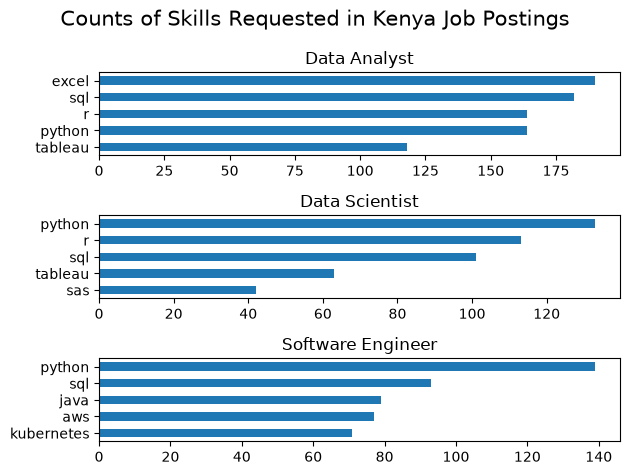

In [33]:
fig, ax=plt.subplots(len(job_titles), 1)

for i, title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
fig.suptitle('Counts of Skills Requested in Kenya Job Postings', fontsize=15)
fig.tight_layout()
plt.show()

In [39]:
job_title_count = df_KE['job_title_short'].value_counts().reset_index(name='jobs_total')

job_title_count

,job_title_short,jobs_total
0,Data Analyst,548
1,Software Engineer,314
2,Data Scientist,242
3,Business Analyst,217
4,Data Engineer,174
5,Cloud Engineer,56
6,Senior Data Analyst,52
7,Senior Data Scientist,46
8,Senior Data Engineer,37
9,Machine Learning Engineer,19


In [43]:
df_skills_perc = pd.merge(df_skills_count, job_title_count, how='left', on='job_title_short')

df_skills_perc['skill_percent'] = 100 * df_skills_perc['skill_count']/df_skills_perc['jobs_total']

df_skills_perc

,job_title_short,job_skills,skill_count,jobs_total,skill_percent
0,Data Analyst,excel,190,548,34.671533
1,Data Analyst,sql,182,548,33.211679
2,Data Analyst,r,164,548,29.927007
3,Data Analyst,python,164,548,29.927007
4,Software Engineer,python,139,314,44.267516
...,...,...,...,...,...
711,Software Engineer,visio,1,314,0.318471
712,Software Engineer,vb.net,1,314,0.318471
713,Business Analyst,confluence,1,217,0.460829
714,Business Analyst,cassandra,1,217,0.460829


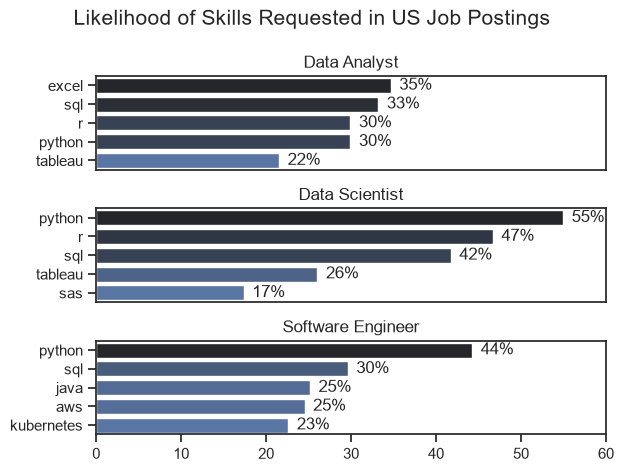

In [60]:
fig, ax=plt.subplots(len(job_titles), 1)

sns.set_theme(style='ticks')

for i, title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == title].head(5)
    # df_plot.plot(kind='barh', x='job_skills', y='skill_percent', ax=ax[i], title=title)
    sns.barplot(df_plot, y='job_skills', x='skill_percent', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 60)
# label the percentage on the bars
    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')

# remove the x-axis tick labels for better readability
    if i != len(job_titles) - 1:
        ax[i].set_xticks([])
fig.suptitle('Likelihood of Skills Requested in US Job Postings', fontsize=15)
fig.tight_layout()
plt.show()